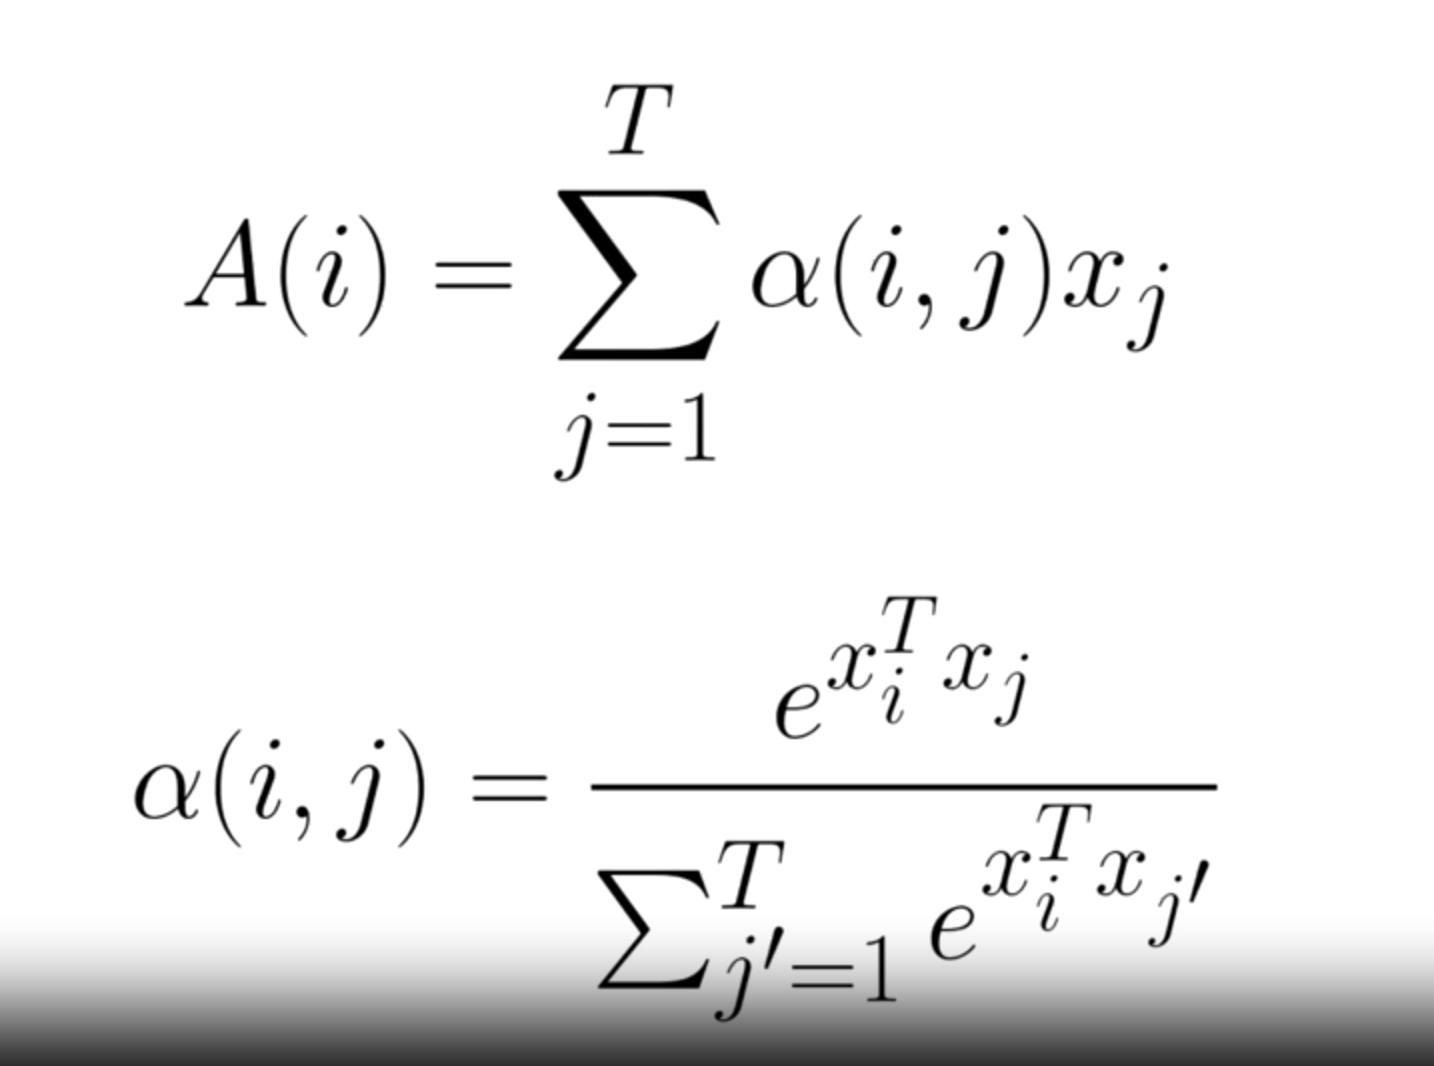

In [55]:
import numpy as np

# 3 words, embedding size 4
X = np.array([
    [1.0, 0.0, 1.0, 0.0],  # "I"
    [0.0, 1.0, 0.0, 1.0],  # "love"
    [1.0, 1.0, 0.0, 0.0],  # "cats"
])

# Notes
# x (seq_length , d_model)

# score -> Example I XI 
#               I X Love
#            I X Cats

# output shape (seq_length x seq_length)
results = []
for i in range(X.shape[0]):
    current_embedding = X[i] # I 
    z =[]
    for j in range(X.shape[1] - 1):
        another_embedding = X[j] # I , Love , Cats
        z.append(current_embedding @ another_embedding)
    results.append(z)
   
# softmax sum->1
sm = []
for e in results:
    all_vals = np.sum(np.exp(e))
    o = []
    for i in e : 
        prob = np.exp(i) / all_vals
        o.append(prob)
    sm.append(o)
sm
# (seq_length , seq_length)

# weighted sum -> w @ x ( 3,3)

output = np.array(sm) @ X

output

array([[0.90996943, 0.33475904, 0.66524096, 0.09003057],
       [0.33475904, 0.90996943, 0.09003057, 0.66524096],
       [0.78805844, 0.78805844, 0.21194156, 0.21194156]])